<a href="https://colab.research.google.com/github/sara2cb/Information-Processing-in-Medical-Imaging/blob/main/Brain_Tumours_Segmentation_using_U_Nets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IPMI20-21 Coursework**
---
#**Brain Tumours Segmentation using U-Nets**

This dataset includes three types of tumour.

The analysis requires graphical processing units, **so before you start, make sure that you are connected to a GPU runtime.**

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import random
import tensorflow as tf

In [ ]:
GLIOMA_LABEL = 2
MENINGIOMA_LABEL = 1
PITUITARY_LABEL = 3
ALL_LABEL = 0

CUR_TESTING = ALL_LABEL

# Get brain tumour data

##Get brain tumor images
Download using the wget system command

In [ ]:
!wget -O images.py --no-check-certificate "https://liveuclac-my.sharepoint.com/:u:/g/personal/ucacjhc_ucl_ac_uk/EYtXUEOdt7VElTHk9lW--l0BY2CqOM4QSk1h5SjrQhRHEQ?e=nmUrKZ&download=1"
!wget -O masks.py --no-check-certificate "https://liveuclac-my.sharepoint.com/:u:/g/personal/ucacjhc_ucl_ac_uk/EcJelcxZRYBNv2FyigSizQUBS6uY3cNuXs42-DZy_0dU0g?e=h0E2gV&download=1"
!wget -O labels.py --no-check-certificate "https://liveuclac-my.sharepoint.com/:u:/g/personal/ucacjhc_ucl_ac_uk/EfXkm777vDVAjCbv_vTTQqYBs5eDOsmuu7Pm2ZgpsT5mPw?e=ZlcrfP&download=1"

--2021-05-02 00:19:36--  https://liveuclac-my.sharepoint.com/:u:/g/personal/ucacjhc_ucl_ac_uk/EYtXUEOdt7VElTHk9lW--l0BY2CqOM4QSk1h5SjrQhRHEQ?e=nmUrKZ&download=1
Resolving liveuclac-my.sharepoint.com (liveuclac-my.sharepoint.com)... 13.107.136.9
Connecting to liveuclac-my.sharepoint.com (liveuclac-my.sharepoint.com)|13.107.136.9|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/ucacjhc_ucl_ac_uk/Documents/Work/Teaching/UCL/IPMI/IPMI%202019-20/brain_tumour_files/images.npy?originalPath=aHR0cHM6Ly9saXZldWNsYWMtbXkuc2hhcmVwb2ludC5jb20vOnU6L2cvcGVyc29uYWwvdWNhY2poY191Y2xfYWNfdWsvRVl0WFVFT2R0N1ZFbFRIazlsVy0tbDBCWTJDcU9NNFFTazFoNVNqclFoUkhFUT9ydGltZT1mczJmLVA4TTJVZw [following]
--2021-05-02 00:19:37--  https://liveuclac-my.sharepoint.com/personal/ucacjhc_ucl_ac_uk/Documents/Work/Teaching/UCL/IPMI/IPMI%202019-20/brain_tumour_files/images.npy?originalPath=aHR0cHM6Ly9saXZldWNsYWMtbXkuc2hhcmVwb2ludC5jb20vOnU6L2cvcGVyc29uYWwvdWNhY2poY191Y2xfYWNfdWsvRVl0WFVFT2

Check the files have loaded and are of the right size (~1.5GB, ~760MB; 25KB)

In [ ]:
!ls -lh *py

-rw-r--r-- 1 root root 1.5G Feb  7  2020 images.py
-rw-r--r-- 1 root root  25K Feb  7  2020 labels.py
-rw-r--r-- 1 root root 767M Feb  7  2020 masks.py


Load image and mask data as numpy arrays

Define dictionary of tumour categories

In [ ]:
integer_to_class = {'1': 'meningioma (1)', '2': 'glioma (2)', '3': 'pituitary tumor (3)'}

Plot the number of scans per tumour type

number of meningioma (1): 708
number of glioma (2): 1426
number of pituitary tumor (3): 930


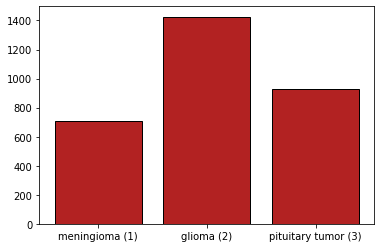

In [ ]:
labels = np.load('labels.py')

classes, counts = np.unique(labels, return_counts=True)
plt.bar(classes, counts,
        tick_label=['meningioma (1)', 'glioma (2)', 'pituitary tumor (3)'],\
        color='firebrick', edgecolor='black')

for i, idx in enumerate(classes):
    print('number of {}: {}'.format(integer_to_class[str(idx)], counts[i]))

## Divide dataset by tumour class

##Create training and test data
Need to randomly select a proportion of data for training and testing

In [ ]:
def train_test_split(image_data, mask_data, labels, train_proportion):
    np.random.seed(38)
    train_proportion = train_proportion
    #Taking random images from the dataset
    train_index = np.random.choice(image_data.shape[0], size = int(image_data.shape[0] * train_proportion), replace = False)
    print(str("Training set = ") + str("{:.0%}".format(train_proportion)) + str(", n = ") + str(len(train_index)))

    x_train = image_data[train_index, :, :]
    x_train = np.expand_dims(x_train, axis=3)

    y_train = mask_data[train_index, :, :]
    y_train = np.expand_dims(y_train, axis=3)

    x_test = np.delete(image_data, train_index, axis=0)
    x_test = np.expand_dims(x_test, axis=3)

    y_test = np.delete(mask_data, train_index, axis=0)
    y_test = np.expand_dims(y_test, axis=3)

    labels_test = np.delete(labels, train_index, axis=0)

    return x_train, y_train, x_test, y_test, labels_test

Generate your training and test data. The inputs here are the images and corresponding mask file.<br>
You can set the proportion of data to be used for training; the remainder will be used for testing.

In [ ]:
#When training all tumours
if CUR_TESTING == 0:
  input_images =  np.load('images.py')
  input_masks =  np.load('masks.py').astype(np.float16)

#When training specific tumours
else:
  input_images =  np.load('images.py')[np.where(labels == CUR_TESTING)]
  input_masks =  np.load('masks.py').astype(np.float16)[np.where(labels == CUR_TESTING)]

# run train_test_split function
x_train, y_train, x_test, y_test, labels_test = train_test_split(image_data = input_images, mask_data = input_masks, labels = labels, train_proportion = 0.8)

Training set = 80%, n = 2451


In [ ]:
print(y_train.shape)
print(x_test.shape)
print(x_test.dtype)
print(y_train.dtype)

(2451, 512, 512, 1)
(613, 512, 512, 1)
int16
float16


## Plot multiple subjects

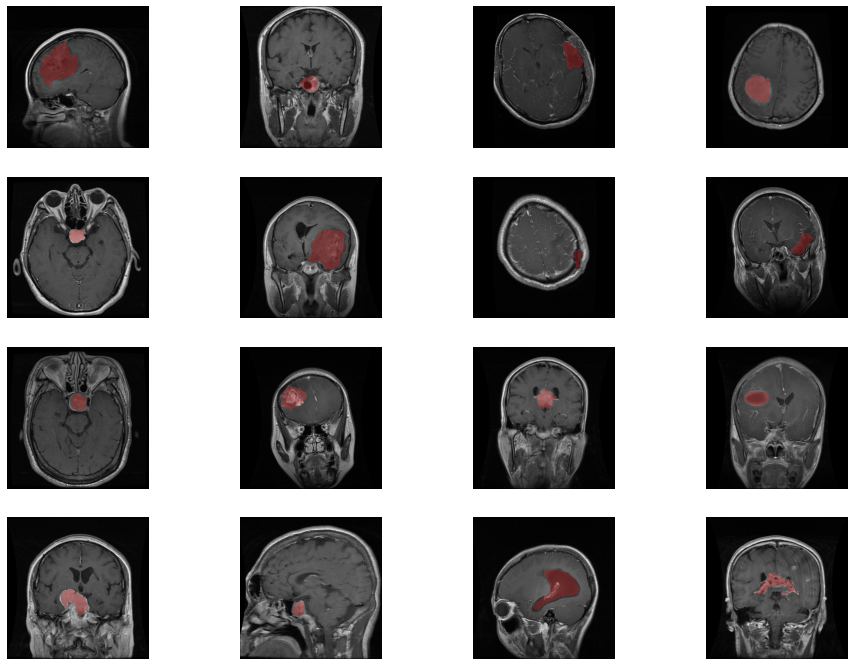

In [ ]:
plt.figure(figsize=(16, 12))
for i, idx in enumerate(np.random.randint(input_images.shape[0], size=16), start=1):
    plt.subplot(4, 4, i)
    plt.imshow(input_images[idx], cmap='gray')

    plt.imshow((np.ma.masked_where(input_masks[idx] == False, input_masks[idx])).astype(float), alpha=0.3, cmap='Set1')
    plt.axis('off')

#U-Net

##Custom performance metrics


In [ ]:
from tensorflow.keras import backend as K
def iou_coef(y_true, y_pred, smooth=1):
  intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
  union = K.sum(y_true,[1,2,3])+K.sum(y_pred,[1,2,3])-intersection
  iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
  return iou

def iou_loss(y_true, y_pred):
    return 1-iou_coef(y_true, y_pred)

smooth = 1.
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)


##Define UNet architecture
#### The following elements can be included the architecture:
- 2D convolution with padded feature maps (for convenience in working out the sizes at different resolution levels)
- nonlinear activation
- pooling layer
- normalisation layer
- dropout

### Convolution block

In [ ]:
def conv2d_block(input_tensor, n_filters, kernel_size = 3, activ_func='relu', batchnorm = True, pad='same'):
    # first layer
    block = tf.keras.layers.Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = pad)(input_tensor)
    if batchnorm:
        block = tf.keras.layers.BatchNormalization()(block)
    block = tf.keras.layers.Activation(activ_func)(block)

    # second layer
    block = tf.keras.layers.Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = pad)(block)
    if batchnorm:
        block = tf.keras.layers.BatchNormalization()(block)
    block = tf.keras.layers.Activation(activ_func)(block)

    return block

### UNet layers

In [ ]:
def unet(input_img, n_filters=16, dropout=0.1, pool_size=(2,2), pad='same'):
  s = tf.keras.layers.Lambda(lambda x: x / 255)(input_img)
  # Contracting path
  c1 = conv2d_block(input_img, n_filters=n_filters)
  c1 = tf.keras.layers.Dropout(dropout)(c1)
  p1 = tf.keras.layers.MaxPooling2D(pool_size = pool_size)(c1)

  c2 = conv2d_block(p1, n_filters=n_filters * 2)
  c2 = tf.keras.layers.Dropout(dropout)(c2)
  p2 = tf.keras.layers.MaxPooling2D(pool_size = pool_size)(c2)

  c3 = conv2d_block(p2, n_filters=n_filters * 4)
  c3 = tf.keras.layers.Dropout(dropout)(c3)
  p3 = tf.keras.layers.MaxPooling2D(pool_size = pool_size)(c3)

  c4 = conv2d_block(p3, n_filters=n_filters * 8)
  c4 = tf.keras.layers.Dropout(dropout)(c4)
  p4 = tf.keras.layers.MaxPooling2D(pool_size = pool_size)(c4)

  c5 = conv2d_block(p4, n_filters=n_filters * 16)
  c5 = tf.keras.layers.Dropout(dropout)(c5)

  # Expanding path
  u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding=pad)(c5)
  u6 = tf.keras.layers.concatenate([u6, c4])
  c6 = tf.keras.layers.Dropout(dropout)(u6)
  c6 = conv2d_block(c6, n_filters=n_filters * 8)

  u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding=pad)(c6)
  u7 = tf.keras.layers.concatenate([u7, c3])
  c7 = tf.keras.layers.Dropout(dropout)(u7)
  c7 = conv2d_block(c7, n_filters=n_filters * 4)

  u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding=pad)(c7)
  u8 = tf.keras.layers.concatenate([u8, c2])
  c8 = tf.keras.layers.Dropout(dropout)(u8)
  c8 = conv2d_block(c8, n_filters=n_filters * 2)

  u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding=pad)(c8)
  u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
  c9 = tf.keras.layers.Dropout(dropout)(u9)
  c9 = conv2d_block(c9, n_filters=n_filters)

  outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
  model = tf.keras.models.Model(inputs=[input_img], outputs=[outputs])
  return model

### Parameters for design

In [ ]:
conv_dropout = 0.1
pool_size_unet = (2,2)
optimizer_lr = 0.001
val_split = 0.2
batch_size = 16
no_epochs = 50
earlyStop_patience = 10
LRPlateau_factor = 0.1
LRPlateau_patience = 5

### Generate model

In [ ]:
IMG_WIDTH = x_train.shape[1]
IMG_HEIGHT = x_train.shape[2]
IMG_CHANNELS = 1
input_img = tf.keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name='img')
model = unet(input_img, dropout=conv_dropout, pool_size=pool_size_unet, pad='same')
adam = tf.keras.optimizers.Adam(lr=optimizer_lr)

loss_func=iou_loss
## compile model
model.compile(optimizer=adam,
              loss=loss_func,
              metrics=[iou_coef, dice_coef, 'accuracy'])


### Train model

In [ ]:
callbacks = [
  tf.keras.callbacks.EarlyStopping(patience=earlyStop_patience, monitor='val_loss'),
  tf.keras.callbacks.ReduceLROnPlateau(factor=LRPlateau_factor, patience=LRPlateau_patience, min_lr=0.00001, verbose=1),
  tf.keras.callbacks.ModelCheckpoint('best_model.h5', verbose=1, save_best_only=True, save_weights_only=True)
]

results = model.fit(x=x_train, y=y_train,
                    validation_split=val_split,
                    batch_size=batch_size,
                    epochs=no_epochs,
                    callbacks=callbacks)

Epoch 1/50
123/123 [==============================] - 71s 402ms/step - loss: 0.9678 - iou_coef: 0.0322 - dice_coef: 0.0609 - accuracy: 0.6096 - val_loss: 0.9554 - val_iou_coef: 0.0445 - val_dice_coef: 0.1008 - val_accuracy: 0.9387

Epoch 00001: val_loss improved from inf to 0.95539, saving model to best_model.h5
Epoch 2/50
123/123 [==============================] - 46s 375ms/step - loss: 0.9394 - iou_coef: 0.0606 - dice_coef: 0.1041 - accuracy: 0.7968 - val_loss: 0.9562 - val_iou_coef: 0.0439 - val_dice_coef: 0.1026 - val_accuracy: 0.9619

Epoch 00002: val_loss did not improve from 0.95539
Epoch 3/50
123/123 [==============================] - 46s 374ms/step - loss: 0.8962 - iou_coef: 0.1038 - dice_coef: 0.1689 - accuracy: 0.9091 - val_loss: 0.9972 - val_iou_coef: 0.0028 - val_dice_coef: 0.0065 - val_accuracy: 0.6707

Epoch 00003: val_loss did not improve from 0.95539
Epoch 4/50
123/123 [==============================] - 46s 375ms/step - loss: 0.7391 - iou_coef: 0.2609 - dice_coef: 0.38

#### Visualise model training

learning rate = 0.000100000005


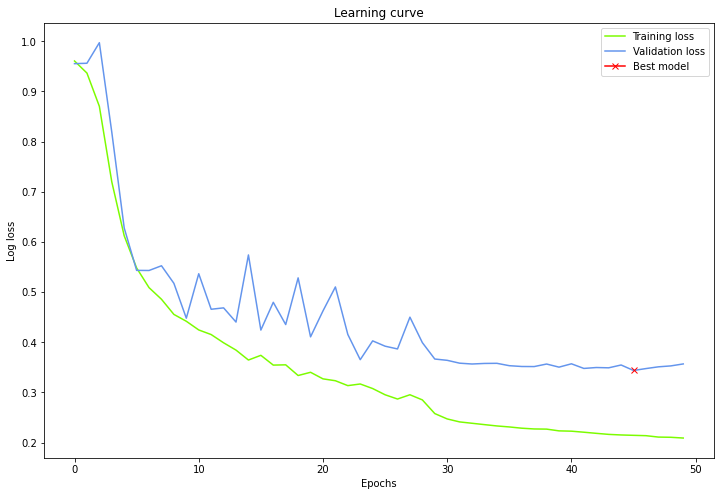

In [ ]:
plt.figure(figsize=(12, 8))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="Training loss", color='lawngreen')
plt.plot(results.history["val_loss"], label="Validation loss", color='cornflowerblue')
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]),
         marker="x", color="red", label="Best model")
plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.legend();

from tensorflow.keras import backend as K
print("learning rate = "  + str(K.eval(model.optimizer.lr)))

#Evaluate performance


In [ ]:
model.load_weights('best_model.h5')
if CUR_TESTING == 0 :
  print('ALL performance')
  model.evaluate(x_test,  y_test, verbose=2)
  print('GLIOMA performance')
  model.evaluate(x_test[labels_test == GLIOMA_LABEL],  y_test[labels_test == GLIOMA_LABEL], verbose=2)
  print('PITUITARY TUMOURS performance')
  model.evaluate(x_test[labels_test == PITUITARY_LABEL],  y_test[labels_test == PITUITARY_LABEL], verbose=2)
  print('MENINGIOMAS performance')
  model.evaluate(x_test[labels_test == MENINGIOMA_LABEL],  y_test[labels_test == MENINGIOMA_LABEL], verbose=2)
else:
  model.evaluate(x_test,  y_test, verbose=2)


ALL performance
20/20 - 5s - loss: 0.3536 - iou_coef: 0.6471 - dice_coef: 0.7677 - accuracy: 0.9923
GLIOMA performance
10/10 - 2s - loss: 0.4873 - iou_coef: 0.5061 - dice_coef: 0.6888 - accuracy: 0.9873
PITUITARY TUMOURS performance
6/6 - 2s - loss: 0.2480 - iou_coef: 0.7521 - dice_coef: 0.8448 - accuracy: 0.9974
MENINGIOMAS performance
5/5 - 1s - loss: 0.2072 - iou_coef: 0.7941 - dice_coef: 0.8930 - accuracy: 0.9962


##Apply to test data

In [ ]:
predict = model.predict(x_test, verbose=1)
predict = (predict > 0.5).astype(np.int8)

20/20 [==============================] - 4s 178ms/step


##Calculate Dice overlap coefficient per subject

GLIOMAS dice overlay
mean = 0.616
median = 0.745
SD = 0.317


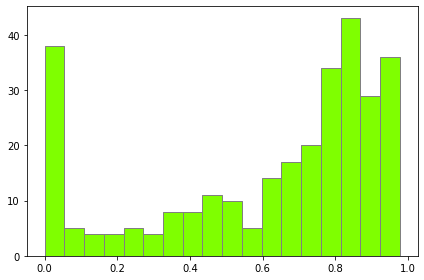

ID = [95]
0.00

PITUITARY TUMOURS dice overlay
mean = 0.840
median = 0.896
SD = 0.174


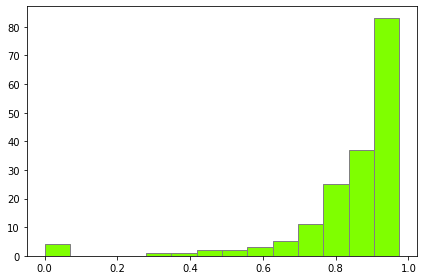

ID = [126]
0.97

MENINGIOMAS dice overlay
mean = 0.859
median = 0.937
SD = 0.203


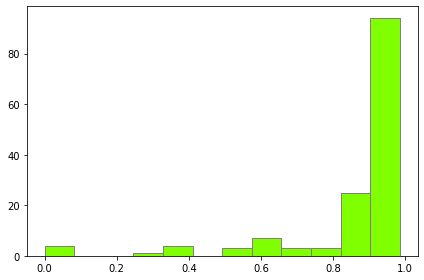

ID = [6]
0.80

ALL dice overlay
mean = 0.737
median = 0.854
SD = 0.283
ID = [27]
0.99


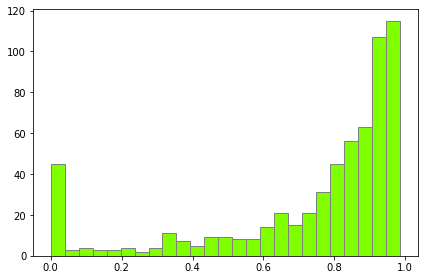

In [ ]:
def get_dice(idx):
  seg = np.squeeze(predict[idx])
  gt = np.squeeze(y_test[idx])
  dice = np.sum(seg[gt==1])*2.0 / (np.sum(seg) + np.sum(gt))
  return dice

if CUR_TESTING == 0 :
  maxDices = []
  titles = ['GLIOMAS', 'PITUITARY TUMOURS', 'MENINGIOMAS']

  #Record dice overlap fro each tumour
  dices_gli = []
  dices_pit = []
  dices_men = []
  for i in range(x_test.shape[0]):
    if labels_test[i] == GLIOMA_LABEL:
      dices_gli.append(get_dice(i))
    elif labels_test[i] == PITUITARY_LABEL:
      dices_pit.append(get_dice(i))
    elif labels_test[i] == MENINGIOMA_LABEL:
      dices_men.append(get_dice(i))

  print("GLIOMAS dice overlay")
  print('mean = ' + '{:.3f}'.format(np.mean(dices_gli)))
  print('median = ' + '{:.3f}'.format(np.median(dices_gli)))
  print('SD = ' + '{:.3f}'.format(np.std(dices_gli)))

  plt.hist(dices_gli, bins='sqrt', facecolor='chartreuse', edgecolor='grey')
  plt.tight_layout()
  plt.show()

  maxDices.append(np.where(dices_gli == np.amax(dices_gli))[0])
  print('ID = ' + str(maxDices[0]))
  print('{:.2f}'.format(get_dice(maxDices[0])))
  print()


  print("PITUITARY TUMOURS dice overlay")
  print('mean = ' + '{:.3f}'.format(np.mean(dices_pit)))
  print('median = ' + '{:.3f}'.format(np.median(dices_pit)))
  print('SD = ' + '{:.3f}'.format(np.std(dices_pit)))

  plt.hist(dices_pit, bins='sqrt', facecolor='chartreuse', edgecolor='grey')
  plt.tight_layout()
  plt.show()

  maxDices.append(np.where(dices_pit == np.amax(dices_pit))[0])
  print('ID = ' + str(maxDices[1]))
  print('{:.2f}'.format(get_dice(maxDices[1])))
  print()


  print("MENINGIOMAS dice overlay")
  print('mean = ' + '{:.3f}'.format(np.mean(dices_men)))
  print('median = ' + '{:.3f}'.format(np.median(dices_men)))
  print('SD = ' + '{:.3f}'.format(np.std(dices_men)))

  plt.hist(dices_men, bins='sqrt', facecolor='chartreuse', edgecolor='grey')
  plt.tight_layout()
  plt.show()

  maxDices.append(np.where(dices_men == np.amax(dices_men))[0])
  print('ID = ' + str(maxDices[2]))
  print('{:.2f}'.format(get_dice(maxDices[2])))

  print()
  print("ALL dice overlay")


dices = []
for i in range(x_test.shape[0]):
  dices.append(get_dice(i))

print('mean = ' + '{:.3f}'.format(np.mean(dices)))
print('median = ' + '{:.3f}'.format(np.median(dices)))
print('SD = ' + '{:.3f}'.format(np.std(dices)))

plt.hist(dices, bins='sqrt', facecolor='chartreuse', edgecolor='grey')
plt.tight_layout()

maxDice = np.where(dices == np.amax(dices))
print('ID = ' + str(maxDice[0]))
print('{:.2f}'.format(get_dice(maxDice[0])))


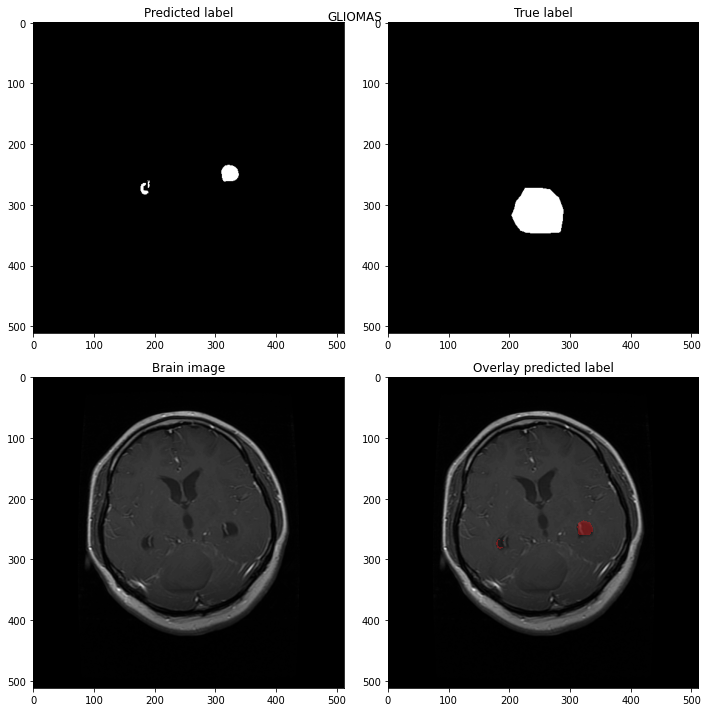

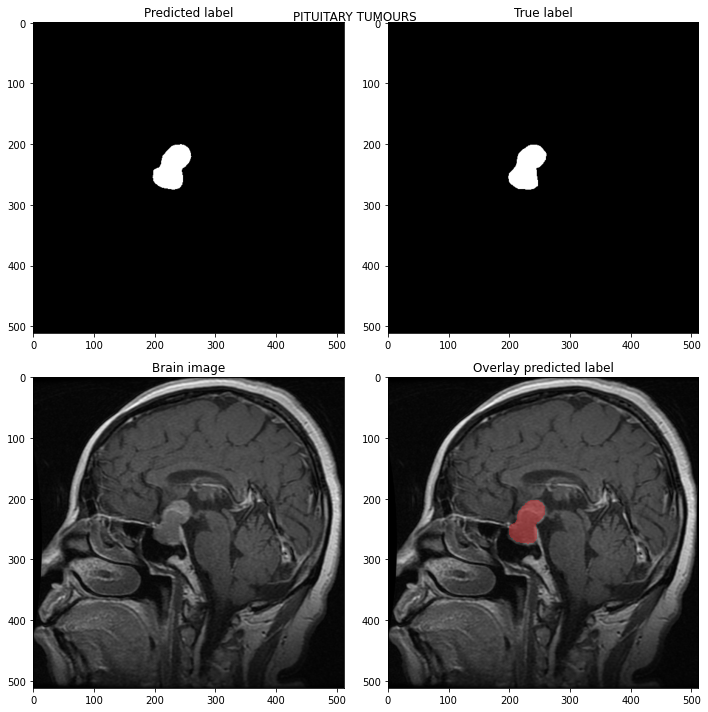

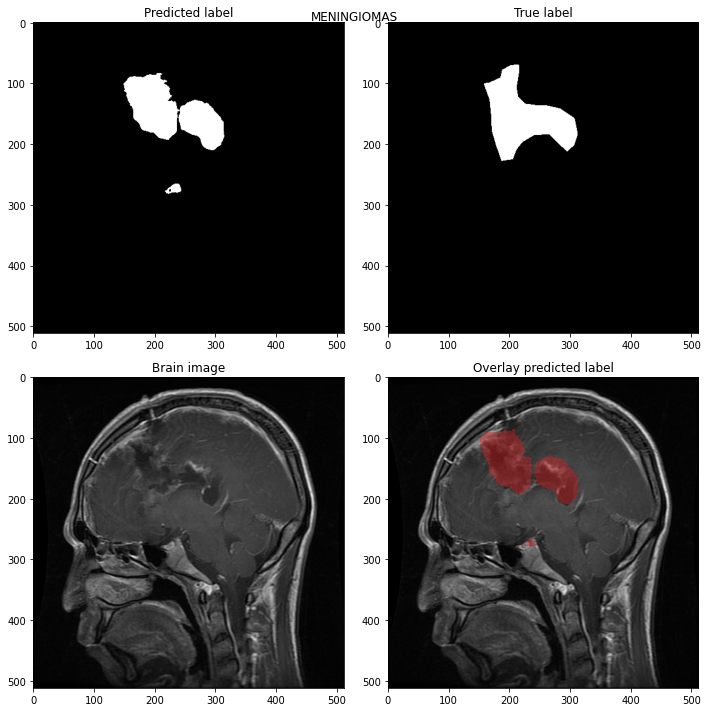

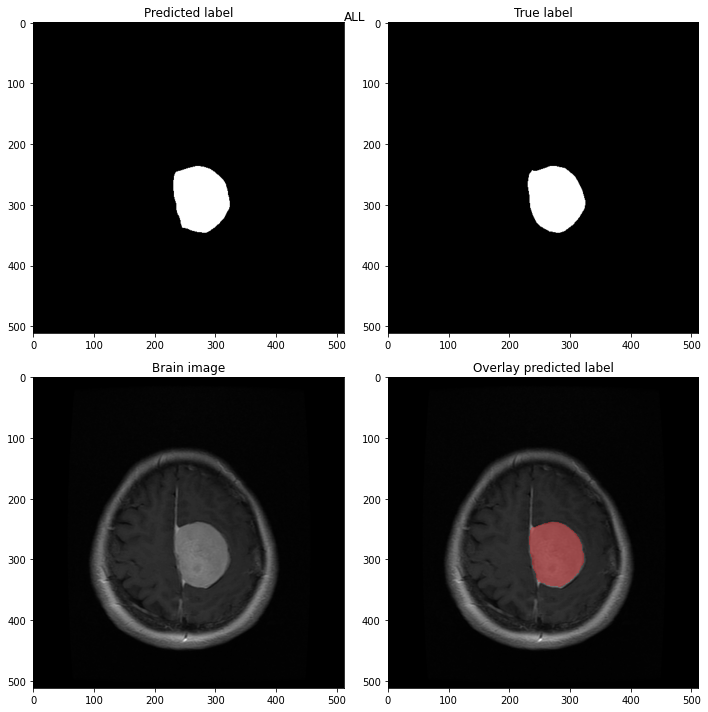

In [ ]:
if CUR_TESTING == 0:
  titles = ['GLIOMAS', 'PITUITARY TUMOURS', 'MENINGIOMAS']

  for l in range(len(titles)):
    idx = maxDices[l]
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
    axes[0,0].imshow(np.squeeze(predict[idx]), cmap='gray')
    axes[0,1].imshow(np.squeeze(y_test[idx].astype(float)), cmap='gray')
    axes[1,0].imshow(np.squeeze(x_test[idx]), cmap='gray')
    axes[1,1].imshow(np.squeeze(x_test[idx]), cmap = 'gray')
    axes[1,1].imshow(np.ma.masked_where(np.squeeze(predict[idx]) == False, np.squeeze(predict[idx])), alpha=0.4, cmap = 'Set1')
    axes[0,0].title.set_text('Predicted label')
    axes[0,1].title.set_text('True label')
    axes[1,0].title.set_text('Brain image')
    axes[1,1].title.set_text('Overlay predicted label')
    fig.suptitle(titles[l])
    plt.tight_layout()


idx = maxDice[0]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
axes[0,0].imshow(np.squeeze(predict[idx]), cmap='gray')
axes[0,1].imshow(np.squeeze(y_test[idx].astype(float)), cmap='gray')
axes[1,0].imshow(np.squeeze(x_test[idx]), cmap='gray')
axes[1,1].imshow(np.squeeze(x_test[idx]), cmap = 'gray')
axes[1,1].imshow(np.ma.masked_where(np.squeeze(predict[idx]) == False, np.squeeze(predict[idx])), alpha=0.4, cmap = 'Set1')
axes[0,0].title.set_text('Predicted label')
axes[0,1].title.set_text('True label')
axes[1,0].title.set_text('Brain image')
axes[1,1].title.set_text('Overlay predicted label')
fig.suptitle("ALL")
plt.tight_layout()

## Correlations between mask volumes

0.767


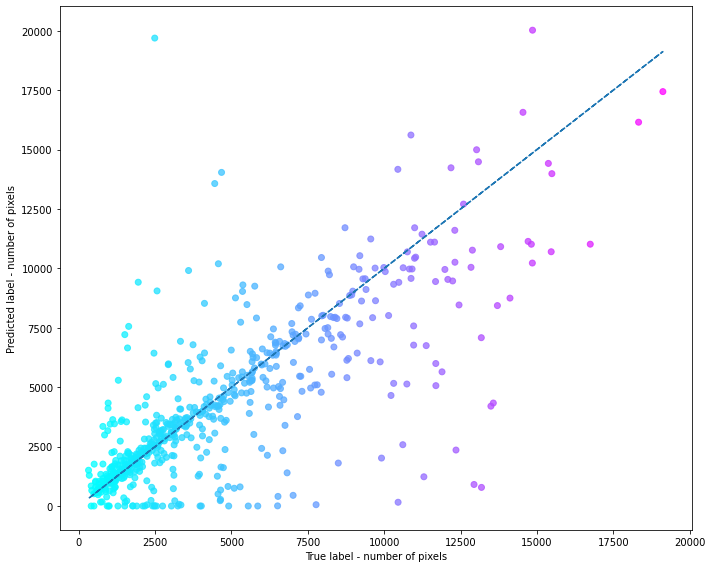

In [ ]:
def get_mask_sizes(idx):
    true_mask_size = np.count_nonzero(y_test[idx])
    predicted_mask_size = np.count_nonzero(predict[idx])
    return true_mask_size, predicted_mask_size

true_masks = [get_mask_sizes(x)[0] for x in range(y_test.shape[0])]
predicted_masks = [get_mask_sizes(x)[1] for x in range(y_test.shape[0])]
print('{:.3f}'.format(np.corrcoef(true_masks, predicted_masks)[0,1]))

plt.figure(figsize=(10,8))
plt.plot(true_masks,true_masks, linestyle='dashed')
plt.scatter(true_masks, predicted_masks, c=true_masks, alpha = 0.75, cmap = 'cool')
plt.xlabel("True label - number of pixels")
plt.ylabel("Predicted label - number of pixels")
plt.tight_layout()